In [1]:
1+1


2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [28]:
file_path =r"..\data\raw\Telco_customer_churn.xlsx"

# Read the Excel file
df = pd.read_excel(file_path)

In [29]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [30]:
# print(df['State'].value_counts())
# print(df['City'].value_counts())
# print(df['Country'].value_counts())
# print(df['Count'].value_counts())
print(df['Churn Reason'].value_counts())
print(df['Zip Code'].value_counts())

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [35]:
columns=['CustomerID','Count','Country','State','Lat Long','Churn Reason','Zip Code','CLTV','Churn Label','Churn Score','Longitude','Latitude']
for c in columns:
    if c in df.columns:
      df.drop(c,inplace=True,axis=1)

In [36]:
df.head()

,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [37]:
df.columns

Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [41]:
df.isnull().sum()
print(df.dtypes)

City                  object
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Value            int64
dtype: object


In [44]:
columm = ['City','Gender','Phone Service','Multiple Lines','Internet Service','Online Security','Online Backup','Device Protection','Tech Support','Streaming TV','Streaming Movies','Contract','Paperless Billing','Payment Method']
for c  in columm:
    if c in df.columns:
     print(df[c].value_counts())

City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Chester            4
Big Bar            4
Washington         4
Stonyford          4
Stirling City      4
Name: count, Length: 1129, dtype: int64
Gender
Male      3555
Female    3488
Name: count, dtype: int64
Phone Service
Yes    6361
No      682
Name: count, dtype: int64
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
Online Backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
Device Protection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


to drop columns 
Phone Services -> as the yes values are 6500 while the no values are about 700 so it can cause model to learn wrong and can overfit



In [12]:
# # Safe check + conditional drop for Phone Service
# from pathlib import Path
# import pandas as pd

# # assume df already loaded
# # Try common possible column names in the Telco dataset
# possible_names = ['PhoneService']

# phone_col = next((c for c in possible_names if c in df.columns), None)
# if phone_col is None:
#     print("No phone-service column found. Columns available:", df.columns.tolist())
# else:
#     counts = df[phone_col].value_counts(dropna=False)
#     props = df[phone_col].value_counts(normalize=True, dropna=False)
#     print(f"Column found: '{phone_col}'")
#     print("Counts:\n", counts)
#     print("Proportions:\n", props)
#     # decide threshold (adjust as needed)
#     threshold = 0.90
#     dominant_share = props.iloc[0]
#     dominant_value = props.index[0]
#     if dominant_share >= threshold:
#         df.drop(columns=[phone_col], inplace=True)
#         print(f"Dropped '{phone_col}' because value '{dominant_value}' makes up {dominant_share:.2%} of rows.")
#     else:
#         print(f"NOT dropped: dominant class share {dominant_share:.2%} < {threshold:.0%}. Consider encoding or class weighting instead.")

In [13]:
df.dtypes

City                  object
Zip Code               int64
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
dtype: object

In [9]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Churn Value'] = pd.to_numeric(df['Churn Value'], errors='coerce')
df['Churn Score'] = pd.to_numeric(df['Churn Score'], errors='coerce')
df['CLTV'] = pd.to_numeric(df['CLTV'], errors='coerce')

In [10]:
df["Average Charges"] = df["Total Charges"] / df["Tenure Months"]

In [11]:
df.dtypes

City                  object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Average Charges      float64
dtype: object

In [13]:
df.columns
print(df.isnull().sum() )

City                  0
Latitude              0
Longitude             0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Label           0
Churn Value           0
Churn Score           0
CLTV                  0
Average Charges      11
dtype: int64


In [17]:
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)
df['Churn Value'].fillna(df['Churn Value'].median(), inplace=True)
df['Average Charges'].fillna(df['Average Charges'].median(), inplace=True)

C:\Users\kusha\AppData\Local\Temp\ipykernel_28636\3654575130.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)
C:\Users\kusha\AppData\Local\Temp\ipykernel_28636\3654575130.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

UNIVARIATE ANALYSIS

1. Numerical Features
   - 'Monthly Charges'
   - 'Churn Value'
   - 'Churn Score'
   - 'CLTV'

<Axes: xlabel='Churn Value', ylabel='Monthly Charges'>

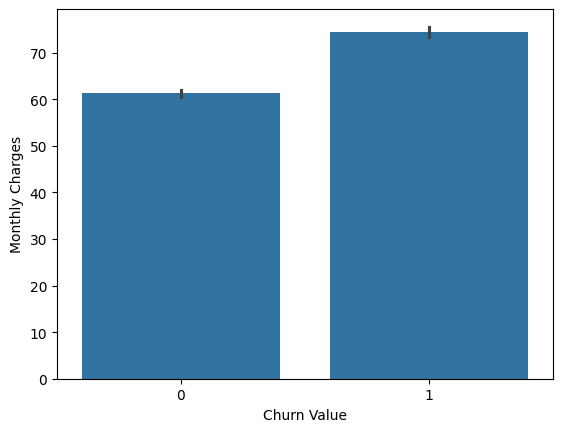

In [20]:
sns.barplot(x='Churn Value', y='Monthly Charges', data=df)

Text(0.5, 1.0, 'Distribution of Average Charges')

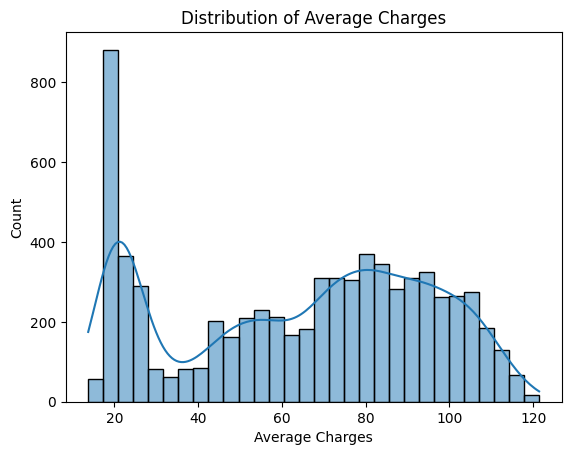

In [21]:
sns.histplot(data=df, x='Average Charges', bins=30, kde=True)
plt.title('Distribution of Average Charges')

<Axes: xlabel='Churn Value', ylabel='Average Charges'>

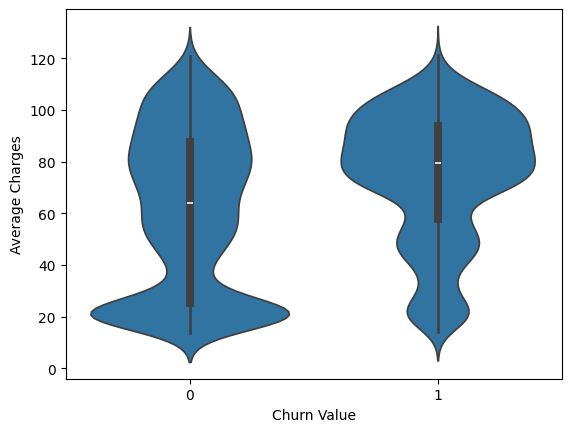

In [22]:
sns.violinplot(x='Churn Value', y='Average Charges', data=df)

Bivariate Analysis

Numerical v Numerical

<Axes: xlabel='Monthly Charges', ylabel='Average Charges'>

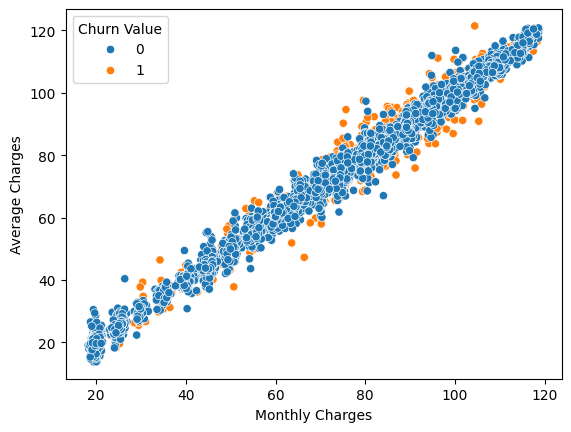

In [ ]:
sns.violinplot(x='Churn Value', y='Average Charges', data=df)

<Axes: xlabel='Average Charges', ylabel='CLTV'>

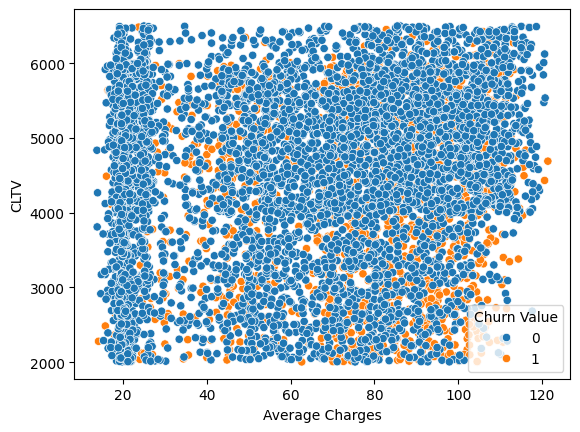

In [24]:
sns.scatterplot(x='Average Charges', y='CLTV', hue='Churn Value', data=df)

Multivariate Analysis

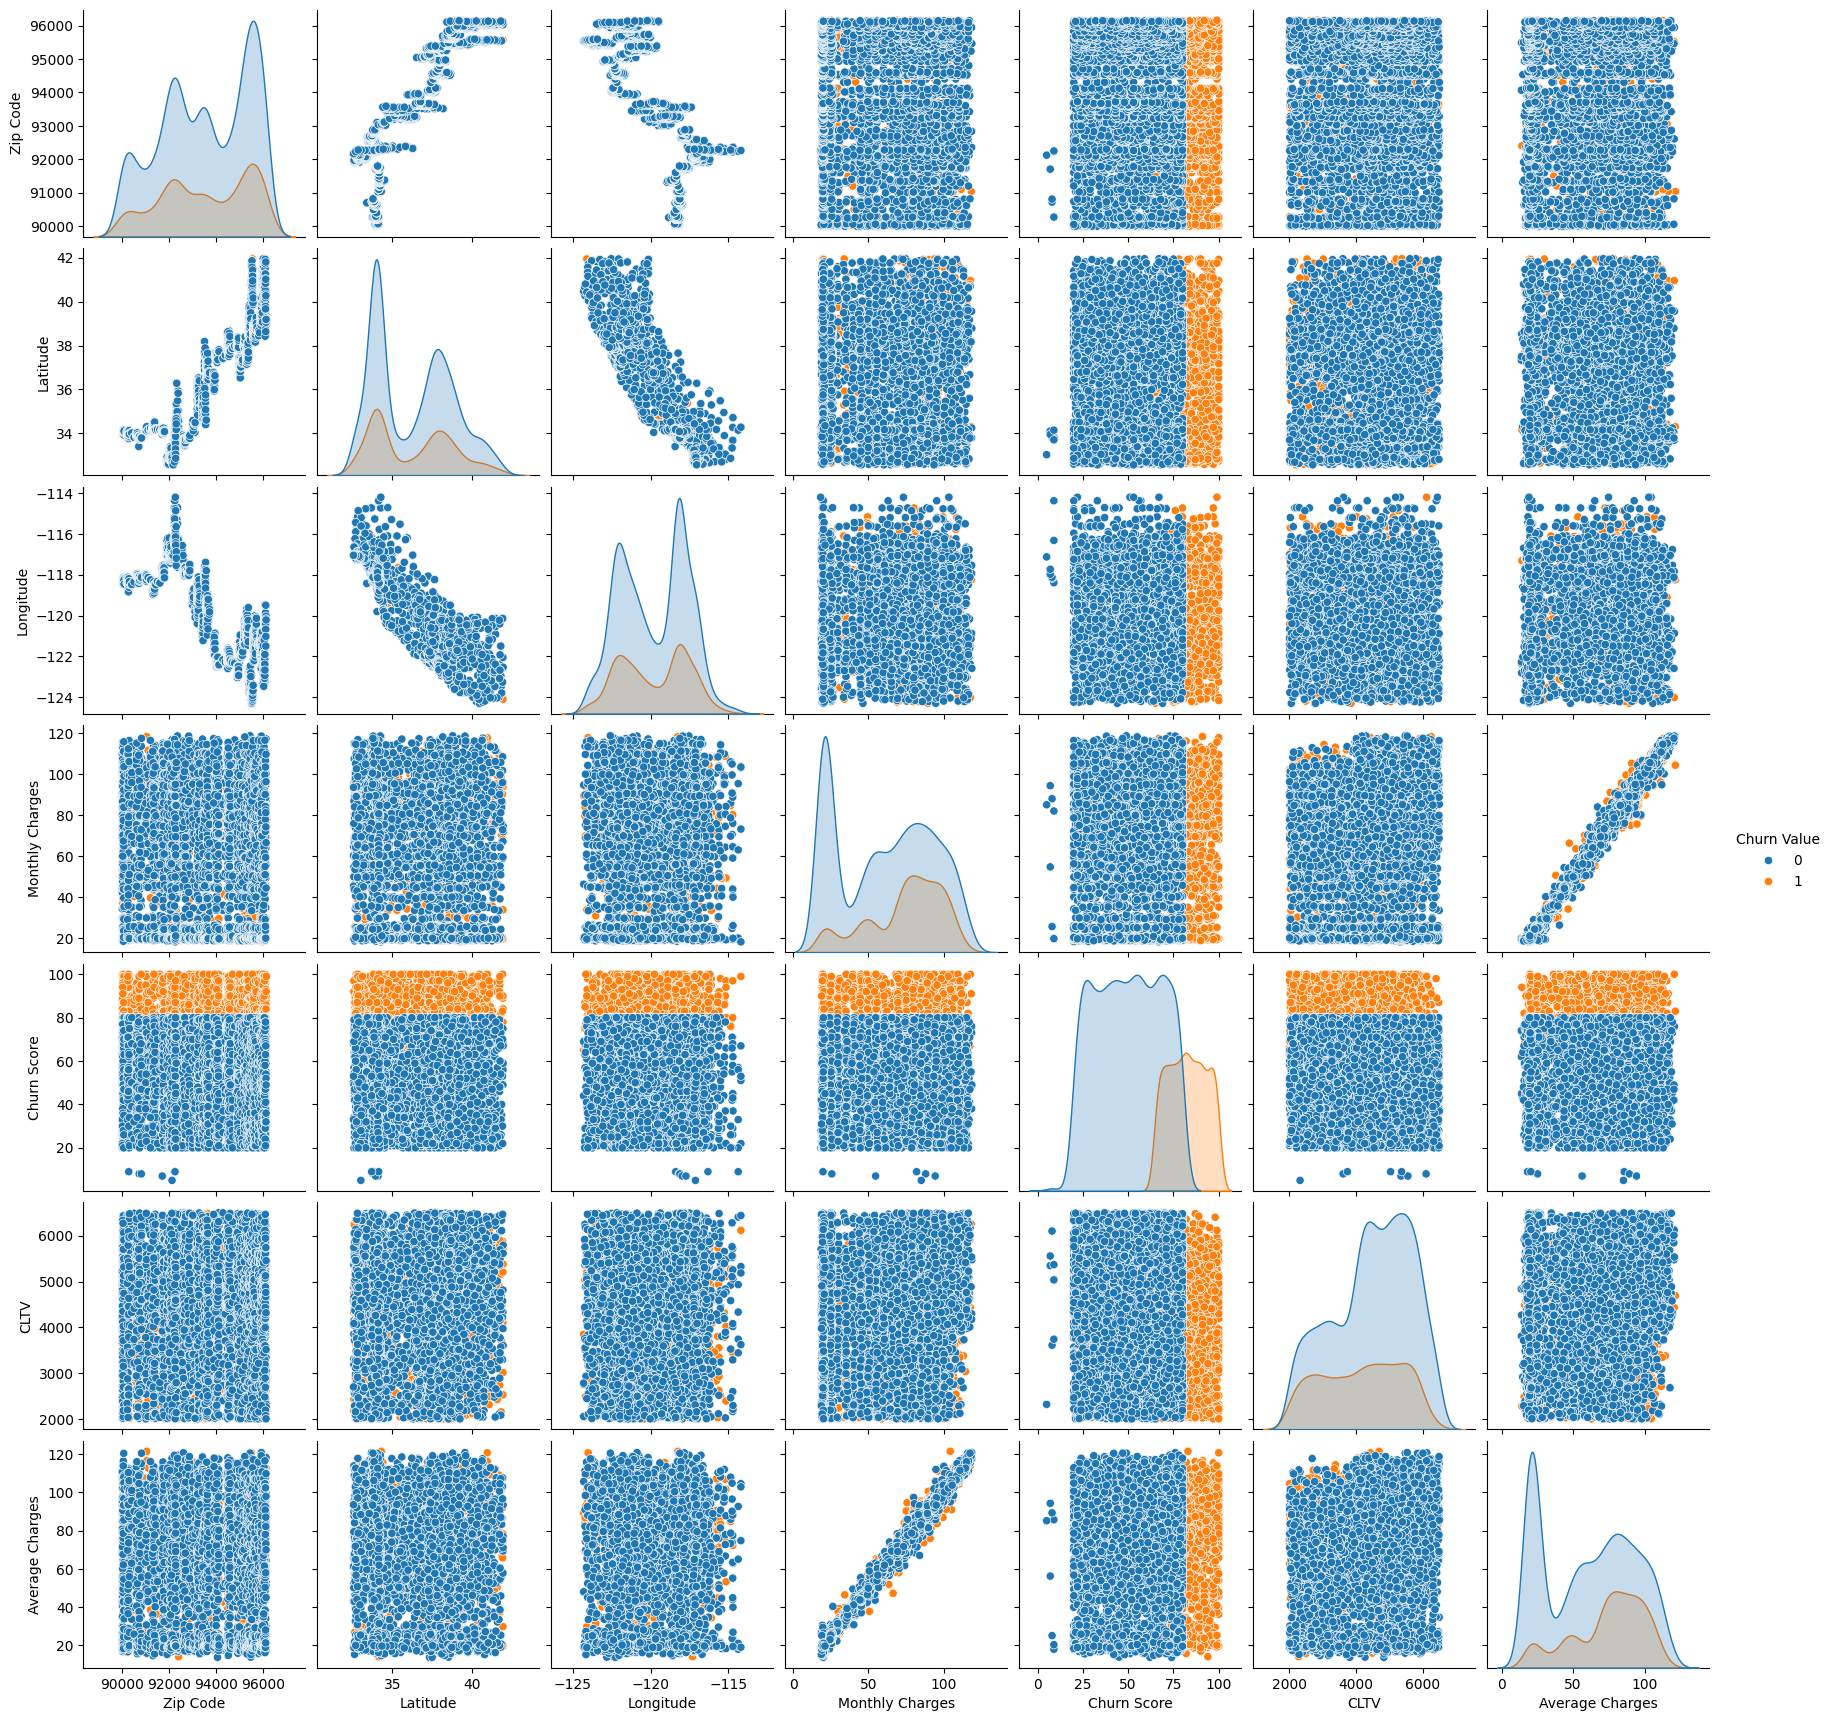

In [ ]:
sns.pairplot(df, hue='Churn Value')

Now we will check for outliers if any and then handle them step by step

In [26]:
df.columns

Index(['City', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Average Charges'],
      dtype='object')

<Axes: xlabel='Churn Value', ylabel='CLTV'>

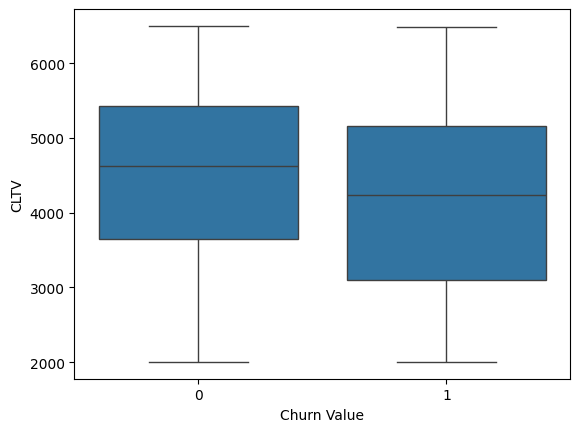

In [27]:
sns.boxplot(x='Churn Value', y='CLTV', data=df)